# ROGUE Purity Audit — per (sample, K, GEP) with split/merge scoring

- `3_rogue_celltype_label_audit.ipynb` — full-transcriptome ROGUE on the original cell-type annotation. **That notebook is the canonical absolute-scale purity reference** for the 17 reference labels; this notebook does not duplicate it. We do recompute the same baseline here in §6 — but on HVGs only, strictly for scale-consistent comparison with §7 (see §6 markdown for full justification).

**What this notebook does.** For every cNMF resolution K and every GEP within K, assign each cell to its argmax-usage GEP and compute ROGUE per **(sample, K, GEP)** on the cNMF HVG substrate. Each row carries the tree label `assign_celltype` gave that GEP in `celltype_gated_correlation.ipynb` as **metadata**, not as the grouping key. A HVG-space baseline ROGUE is computed for both specific labels (§6) and family pools (§6b); the two tables are then joined per `(sample, K, GEP)` so we can ask, for each GEP at each K, whether its cell subset is purer than the original-annotation block whose label it carries.


## Split/merge logic

For each `(sample, K, GEP)` row, the tree label points us to a baseline:

* **Specific label** (e.g. `cDC2_CD1C`): baseline = HVG ROGUE of the original `cDC2_CD1C` cells in that sample. `Δ ROGUE > 0` means cNMF found a purer subset of the original annotation → **evidence for splitting** the original label.
* **Family label** (e.g. `Monocyte_family`): baseline = HVG ROGUE of the union of the constituent original labels (`Mono_CD14`, `Mono_CD16`, …) in that sample. Three reference points are computed — `mean`, `min`, `max` ROGUE across the constituents. If the family GEP beats the *max*, the family-level grouping is strictly purer than any single constituent → **evidence for merging** the constituent labels.
* **Ambiguous/Mixed**: no baseline; reported individually. High ROGUE here means the GEP is internally coherent but didn't pass the dominance threshold in §3 of notebook 2 — useful for tuning `AMBIGUITY_THRESHOLD`.

## Gene-space convention

All ROGUE values in this notebook are on the **same 5K HVG matrix** used by cNMF — both the per-GEP scores and both baselines. This makes Δ ROGUE interpretable as "the GEP found a purer subset *in the same gene space*." The absolute values are systematically lower than the full-transcriptome scores in notebook 3 and should not be compared to the 0.9 threshold from Liu et al. (2020); use notebook 3's CSV for that.

**Reference:** Liu et al., *Nat Commun* (2020). https://github.com/PaulingLiu/ROGUE


In [1]:
import os
import glob
import re
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import time
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr

CONVERTER = ro.default_converter + pandas2ri.converter + numpy2ri.converter

rogue_r = importr('ROGUE')
tibble  = importr('tibble')

## 1. Config


In [2]:
ADATA_PATH = "data/hnc_myeloid_2021.h5ad"
COUNTS_LAYER = None

METADATA_PATH = "data/hnc_myeloid_globalcluster4.csv"
BARCODE_COL   = None
METADATA_SEP  = ","

CNMF_DIR          = "hnc_consensus_outputs_k3-35/combined_hnc_k_consensus_outputs"
CNMF_PREFIX       = "combined_hnc_k"
DENSITY_THRESHOLD = "0_01"
K_MIN, K_MAX = 3, 35

# Per-GEP label table from celltype_gated_correlation.ipynb (cell §3.6)
# Schema: k (int), gep (str), label (str: specific celltype | "<family>_family" | "Ambiguous/Mixed")
LABELS_PATH        = "combined-hnc_k3-35_corr-tree_kl-divergence/per_gep_labels.tsv"
LABELS_SEP         = "\t"
AMBIGUOUS_LABEL    = "Ambiguous/Mixed"
DROP_AMBIGUOUS     = False

BASELINE_LABEL_COL = "global.cluster4"

# Notebook 3's full-transcriptome ROGUE baseline — kept for cross-reference in §6 only.
# NOT loaded here: per-GEP ROGUE in §7 runs on HVGs, and Δ ROGUE must stay in the same gene space.
NB3_BASELINE_PATH = "rogue_purity_results_celltype/rogue_celltype_audit.csv"

# Family definitions — MUST match notebook 2.
CELLTYPE_FAMILIES = {
    "Monocyte":   ["Mono_CD14", "Mono_CD14_ID1", "Mono_CD14_IL1B", "Mono_CD14_THBS1",
                   "Mono_CD16", "Mono_Int", "Mono_TIL"],
    "DC":         ["cDC1_CLEC9A", "cDC2_CD1C", "cDC2_CD33", "mregDC_LAMP3"],
    "Macrophage": ["Mac_CXCL9", "Mac_IL1B", "Mac_IL1Bint", "Mac_SPP1"],
}
FAMILY_LABEL_SUFFIX = "_family"

ROGUE_PLATFORM = "UMI"
ROGUE_SPECIES  = "Human"
ROGUE_K        = 45
MIN_CELLS_PER_GROUP = 15

N_HVG = 5000

DELTA_ROGUE_THRESHOLD = 0.05

OUT_DIR = "rogue_purity_results_per_gep"
os.makedirs(OUT_DIR, exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 2. Load raw counts + metadata

In [3]:
adata = sc.read_h5ad(ADATA_PATH)
print(f"AnnData: {adata.shape}")

# Get raw counts as a dense genes × cells matrix (ROGUE expects this orientation)
X = adata.layers[COUNTS_LAYER] if COUNTS_LAYER else adata.X
if sparse.issparse(X):
    X = X.toarray()
X = X.astype(np.float64)

# Sanity check: ROGUE assumes raw counts (integer-valued, non-negative)
if not np.allclose(X, np.round(X)):
    raise ValueError("Matrix doesn't look like raw counts — check COUNTS_LAYER.")

counts_df = pd.DataFrame(X.T, index=adata.var_names, columns=adata.obs_names)
print(f"Counts matrix (genes × cells): {counts_df.shape}")

# Metadata (used for per-cell sample IDs AND original cell-type annotation)
meta = pd.read_csv(METADATA_PATH, sep=METADATA_SEP,
                   index_col=0 if BARCODE_COL is None else None)
if BARCODE_COL is not None:
    meta = meta.set_index(BARCODE_COL)
meta.index = meta.index.astype(str)

common = counts_df.columns.intersection(meta.index)
counts_df = counts_df[common]
meta = meta.loc[common]
meta['orig.ident'] = adata.obs.loc[meta.index, 'orig.ident'].astype(str)
samples = meta['orig.ident']
original_labels = meta[BASELINE_LABEL_COL].astype(str)
print(f"Aligned to {len(common)} cells")
print(f"Original annotation column ('{BASELINE_LABEL_COL}') values:")
print(original_labels.value_counts().to_string())

AnnData: (26444, 23630)
Counts matrix (genes × cells): (23630, 26444)
Aligned to 26444 cells
Original annotation column ('global.cluster4') values:
global.cluster4
Mono_CD14          7518
Mono_CD16          2503
Mac_IL1Bint        1842
Mono_CD14_IL1B     1801
Mono_CD14_THBS1    1783
Mono_Int           1684
cDC2_CD33          1319
Mac_CXCL9          1225
DC_pDC             1218
Mono_CD14_ID1      1154
Mono_TIL            988
cDC2_CD1C           966
Mac_IL1B            774
Mac_SPP1            573
mregDC_LAMP3        482
Mast                313
cDC1_CLEC9A         301


## 3. ROGUE wrapper

Calls the R `rogue()` function on a counts matrix + per-cell labels and
returns a tidy `(sample, cluster, ROGUE, n_cells)` long table. `cluster` here
is whatever label series you pass — in §6 it's the **GEP id**, in §5 it's the
**original cell-type annotation**, in §5b it's the **family name**.


In [4]:
def compute_rogue(counts_df, labels, samples=None,
                  platform=ROGUE_PLATFORM, species=ROGUE_SPECIES,
                  k=ROGUE_K, min_cells=MIN_CELLS_PER_GROUP,
                  verbose=True):
    """
    counts_df : DataFrame (genes × cells), raw counts
    labels    : Series indexed by cell barcode → cluster label
    samples   : Series indexed by cell barcode → sample/patient ID, or None
    Returns   : (long DataFrame [sample, cluster, ROGUE, n_cells],
                 wide DataFrame [samples × clusters])
    """
    # --- Filter tiny groups ---
    label_counts = labels.value_counts()
    keep = label_counts[label_counts >= min_cells].index
    dropped = sorted(set(label_counts.index) - set(keep))
    if dropped and verbose:
        print(f"Skipping {len(dropped)} cluster(s) below {min_cells} cells: {dropped}")

    cells = labels[labels.isin(keep)].index
    counts_sub = counts_df[cells]
    labels_sub = labels.loc[cells].astype(str)
    samples_sub = (pd.Series("all", index=cells) if samples is None
                   else samples.loc[cells].astype(str))

    # --- Build (sample, cluster) work list ---
    pairs = (pd.DataFrame({'sample': samples_sub.values, 'cluster': labels_sub.values})
               .value_counts()
               .reset_index(name='n_cells'))
    pairs = pairs[pairs['n_cells'] >= min_cells].reset_index(drop=True)

    if verbose:
        print(f"Counts: {counts_sub.shape[0]:,} genes × {counts_sub.shape[1]:,} cells")
        print(f"Computing ROGUE for {len(pairs)} (sample, cluster) pair(s)")
        print()

    # --- Push the full counts matrix to R once ---
    with CONVERTER.context():
        ro.globalenv['expr_full'] = counts_sub
    ro.r("""
        suppressMessages(library(ROGUE))
        expr_full <- as.matrix(expr_full)
    """)

    # --- Per-(sample, cluster) loop in Python ---
    results = []
    t_total = time.time()
    iterator = tqdm(list(pairs.itertuples(index=False)),
                    total=len(pairs), disable=not verbose,
                    desc="ROGUE")

    for row in iterator:
        s, ct, n = row.sample, row.cluster, row.n_cells
        in_mask = (samples_sub == s) & (labels_sub == ct)
        sub_cells = labels_sub.index[in_mask].tolist()

        with CONVERTER.context():
            ro.globalenv['cells_keep'] = ro.StrVector(sub_cells)

        t0 = time.time()
        try:
            ro.r(f"""
                expr_mat  <- expr_full[, cells_keep, drop=FALSE]
                expr_mat  <- matr.filter(expr_mat, min.cells = 10, min.genes = 10)
                ent_res   <- SE_fun(expr_mat, span = 0.6, mt.method = "fdr")
                rogue_val <- CalculateRogue(ent_res, platform = "{platform}", k = {k})
            """)
            with CONVERTER.context():
                rogue_val = float(ro.r('rogue_val')[0])
            ok = True
        except Exception as e:
            rogue_val = float('nan')
            ok = False
            if verbose:
                tqdm.write(f"  ✗ {s} / {ct}: FAILED — {e}")

        elapsed = time.time() - t0
        if ok and verbose:
            tqdm.write(f"  ✓ {s} / {ct:<25} ROGUE={rogue_val:.3f}  "
                       f"(n={n:>4}, {elapsed:>4.1f}s)")

        results.append({'sample': s, 'cluster': ct,
                        'ROGUE': rogue_val, 'n_cells': n})

    total = time.time() - t_total
    if verbose:
        avg = total / max(len(pairs), 1)
        print(f"\nDone in {total:.1f}s total ({avg:.1f}s/cluster avg)")

    long = pd.DataFrame(results).dropna(subset=['ROGUE']).reset_index(drop=True)
    wide = long.pivot(index='sample', columns='cluster', values='ROGUE')
    return long, wide

## 4. Load per-GEP labels from the correlation-tree pipeline

We need the per-`(K, GEP)` label that `celltype_gated_correlation.ipynb`
produced — specifically the **complete** label table written by its §3.6 cell
(`per_gep_labels.tsv`). Each row tells us, for one GEP at one K, the final
label `assign_celltype` gave it:

- a specific cell type (e.g. `cDC2_CD1C`)
- a family label (e.g. `Monocyte_family`)
- the literal string `"Ambiguous/Mixed"`

We normalize `gep` to a string here because that's what `usage.idxmax(axis=1)`
returns in §6.


In [5]:
labels_df = pd.read_csv(LABELS_PATH, sep=LABELS_SEP)
required_cols = {"k", "gep", "label"}
missing = required_cols - set(labels_df.columns)
if missing:
    raise ValueError(
        f"per-GEP labels TSV is missing columns {missing}. "
        f"Expected schema: k, gep, label. Got: {list(labels_df.columns)}"
    )

labels_df['k']     = labels_df['k'].astype(int)
labels_df['gep']   = labels_df['gep'].astype(str)
labels_df['label'] = labels_df['label'].astype(str)

# Build a fast lookup: (k, gep_id) -> label
label_lookup = (labels_df
                .set_index(['k', 'gep'])['label']
                .to_dict())

print(f"Loaded labels for {len(labels_df)} (k, gep) entries "
      f"across K = {sorted(labels_df['k'].unique())}")
print(f"Unique labels: {sorted(labels_df['label'].unique())}")
n_amb = (labels_df['label'] == AMBIGUOUS_LABEL).sum()
print(f"  ({n_amb} GEPs labeled '{AMBIGUOUS_LABEL}')")

# Cross-check: every specific label in the TSV should be a known cell type
# in the baseline annotation, otherwise the §7 join will fail silently.
known_originals = set(original_labels.unique())
known_families  = {f"{fam}{FAMILY_LABEL_SUFFIX}" for fam in CELLTYPE_FAMILIES}
unknown = (set(labels_df['label']) - known_originals - known_families - {AMBIGUOUS_LABEL})
if unknown:
    print(f"  ⚠ Labels in TSV not found in the original annotation OR "
          f"the family definitions: {sorted(unknown)}.")
    print("    These rows will be flagged 'no_baseline' in §7.")

Loaded labels for 627 (k, gep) entries across K = [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35)]
Unique labels: ['Ambiguous/Mixed', 'DC_family', 'DC_pDC', 'Mac_IL1B', 'Mac_SPP1', 'Macrophage_family', 'Mast', 'Mono_CD14_ID1', 'Mono_CD16', 'Monocyte_family', 'cDC2_CD33']
  (452 GEPs labeled 'Ambiguous/Mixed')


### 4b. Diagnostic — which specific subtypes did `assign_celltype` actually emit?

Catches **filter 1**: a family constituent (e.g. `cDC2_CD1C`) is part of
`CELLTYPE_FAMILIES` but never appears as a specific label in the per-GEP TSV
because every GEP that should have carried it failed the
`AMBIGUITY_THRESHOLD` dominance check in notebook 2 and got rerouted to
`<family>_family` or `Ambiguous/Mixed`. These subtypes are invisible to
every downstream step of this notebook — they have no row in §6, no row in
§7, no row in §10. Without this check, that silent absence looks the same
as "no signal."


In [6]:
# Which specific subtypes did assign_celltype emit at least once?
specific_in_tsv = set(labels_df.loc[
    (labels_df['label'] != AMBIGUOUS_LABEL)
    & (~labels_df['label'].str.endswith(FAMILY_LABEL_SUFFIX)),
    'label'
].unique())

# Universe of subtypes we *expected* to see (family constituents).
# Other specific labels (e.g. lymphoid/non-myeloid) outside any family are
# not checked here — they're either present in `specific_in_tsv` or were
# never relevant to begin with.
all_family_constituents = {ct
                           for cts in CELLTYPE_FAMILIES.values()
                           for ct in cts}

never_labeled = sorted(all_family_constituents - specific_in_tsv)
labeled_constituents = sorted(all_family_constituents & specific_in_tsv)

print(f"Family-constituent subtypes that DID get a specific label "
      f"at some K: {len(labeled_constituents)}/{len(all_family_constituents)}")
for ct in labeled_constituents:
    n_geps = (labels_df['label'] == ct).sum()
    n_K = labels_df.loc[labels_df['label'] == ct, 'k'].nunique()
    print(f"  ✓ {ct:<22} {n_geps:>4} GEPs across {n_K:>2} K values")

if never_labeled:
    print(f"\n⚠ Family-constituent subtypes NEVER emitted as a specific label "
          f"by assign_celltype: {never_labeled}")
else:
    print("\n✓ Every family constituent appears as a specific label at "
          "least once.")


Family-constituent subtypes that DID get a specific label at some K: 5/15
  ✓ Mac_IL1B                  2 GEPs across  2 K values
  ✓ Mac_SPP1                  4 GEPs across  4 K values
  ✓ Mono_CD14_ID1             4 GEPs across  4 K values
  ✓ Mono_CD16                 9 GEPs across  9 K values
  ✓ cDC2_CD33                 4 GEPs across  4 K values

⚠ Family-constituent subtypes NEVER emitted as a specific label by assign_celltype: ['Mac_CXCL9', 'Mac_IL1Bint', 'Mono_CD14', 'Mono_CD14_IL1B', 'Mono_CD14_THBS1', 'Mono_Int', 'Mono_TIL', 'cDC1_CLEC9A', 'cDC2_CD1C', 'mregDC_LAMP3']


## 5. Select the 5K highly variable genes (cNMF substrate)

We compute HVGs once on the raw counts using `flavor='seurat_v3'` (which is
designed for un-normalized counts and is what cNMF's own pipeline uses
internally). **Both** the per-GEP ROGUE in §6 **and** the baseline ROGUE in §6b
operate on `counts_df_hvg` so the two are directly comparable.

**Gene-space caveat:** ROGUE's S-E test is calibrated against the
whole-transcriptome mean–variance trend, and restricting to pre-selected HVGs
biases the entropy reference. Absolute ROGUE values in this notebook are not
comparable to the full-transcriptome run in the cell-type audit notebook or to
the 0.9 threshold from Liu et al. (2020). All split/merge claims are made on
**Δ ROGUE within this HVG space**, so the bias cancels.


In [7]:
_hvg_adata = ad.AnnData(
    X=counts_df.T.values,
    obs=pd.DataFrame(index=counts_df.columns),
    var=pd.DataFrame(index=counts_df.index),
)

sc.pp.highly_variable_genes(
    _hvg_adata,
    n_top_genes=N_HVG,
    flavor='seurat_v3',
    subset=False,
)

hvg_genes = _hvg_adata.var_names[_hvg_adata.var['highly_variable']].tolist()
print(f"Selected {len(hvg_genes)} HVGs out of {counts_df.shape[0]} total genes.")

counts_df_hvg = counts_df.loc[hvg_genes]
print(f"HVG counts matrix (genes × cells): {counts_df_hvg.shape}")

hvg_path = os.path.join(OUT_DIR, f"hvg_genes_n{N_HVG}_seuratv3.txt")
pd.Series(hvg_genes).to_csv(hvg_path, index=False, header=False)
print(f"  → saved gene list to {hvg_path}")

del _hvg_adata

Selected 5000 HVGs out of 23630 total genes.
HVG counts matrix (genes × cells): (5000, 26444)
  → saved gene list to rogue_purity_results_per_gep/hvg_genes_n5000_seuratv3.txt


## 6. Baseline ROGUE — specific original cell-type labels (HVG space)

The per-GEP ROGUE in §7 runs on the 5K HVG cNMF substrate, not the full transcriptome. ROGUE's S-E test is calibrated against whatever mean–variance trend is in the input matrix, so an HVG-restricted run and a full-transcriptome run produce different absolute ROGUE values for the same cells. If we used notebook 3's baseline directly,
the §8 Δ ROGUE comparison would mix gene spaces, and a positive Δ could mean "the GEP found a purer subset" *or* "the GEP just got a more lenient entropy reference by being on HVGs." Comparing within a single gene space is the only way to make Δ ROGUE interpretable as a split/merge signal.

In [8]:
baseline_specific_path = os.path.join(OUT_DIR, "rogue_baseline_specific.csv")

if os.path.exists(baseline_specific_path):
    baseline_specific = pd.read_csv(baseline_specific_path)
    print(f"Loaded cached specific-label baseline: {baseline_specific_path}")
else:
    print("Computing per-(sample, original cell type) baseline ROGUE …")
    baseline_specific, _ = compute_rogue(
        counts_df_hvg,
        labels=original_labels,
        samples=samples,
    )
    baseline_specific = baseline_specific.rename(columns={'cluster': 'original_label'})
    baseline_specific.to_csv(baseline_specific_path, index=False)
    print(f"  → saved {baseline_specific_path}")

# Per-sample lookup: (sample, original_label) -> baseline ROGUE
baseline_specific_lookup = (baseline_specific
                            .set_index(['sample', 'original_label'])['ROGUE']
                            .to_dict())
print(f"\nBaseline (specific labels): {len(baseline_specific)} (sample, label) pairs")
print(baseline_specific.groupby('original_label')['ROGUE']
                        .agg(['mean', 'median', 'count'])
                        .round(3).to_string())

Loaded cached specific-label baseline: rogue_purity_results_per_gep/rogue_baseline_specific.csv

Baseline (specific labels): 312 (sample, label) pairs
                  mean  median  count
original_label                       
DC_pDC           0.928   0.944     30
Mac_CXCL9        0.810   0.824     13
Mac_IL1B         0.825   0.831     10
Mac_IL1Bint      0.794   0.794     21
Mac_SPP1         0.801   0.808      7
Mast             0.943   0.950      7
Mono_CD14        0.976   0.976     36
Mono_CD14_ID1    0.936   0.943      5
Mono_CD14_IL1B   0.953   0.962     24
Mono_CD14_THBS1  0.969   0.983     11
Mono_CD16        0.958   0.964     33
Mono_Int         0.969   0.970     27
Mono_TIL         0.862   0.855     13
cDC1_CLEC9A      0.895   0.909      6
cDC2_CD1C        0.781   0.791     21
cDC2_CD33        0.927   0.934     36
mregDC_LAMP3     0.864   0.873     12


### 6b. Baseline ROGUE — family pools (HVG space)

For each family in `CELLTYPE_FAMILIES`, pool every cell whose original annotation is one of the family's constituents and compute ROGUE per`(sample, family_pool)`. This is the baseline a family-labeled GEP is compared against — "is the family GEP's purity higher than what we'd get by simply merging the originals?"

Two extra reference points are derived per `(sample, family)` from the §6 specific baselines:

- `mean_constituent_ROGUE` — average purity of the originals being merged.
- `max_constituent_ROGUE` — purity of the *best* constituent.

The pool ROGUE answers "is the family pool itself coherent?", while `max_constituent_ROGUE` answers "does the family GEP beat the best original it represents?" — a stricter merge criterion. §8 records all three so the recommendation classifier can use whichever is appropriate.

(Same gene space as §6 — HVGs — for the same scale-consistency reason.)

In [9]:
baseline_family_path = os.path.join(OUT_DIR, "rogue_baseline_family.csv")

# Build a cell -> family label series for the pool ROGUE
ct_to_family = {ct: fam for fam, cts in CELLTYPE_FAMILIES.items() for ct in cts}
family_labels_per_cell = original_labels.map(
    lambda ct: f"{ct_to_family[ct]}{FAMILY_LABEL_SUFFIX}" if ct in ct_to_family else None
).dropna()
print(f"Cells in any family pool: {len(family_labels_per_cell)} "
      f"(across {family_labels_per_cell.nunique()} families)")

if os.path.exists(baseline_family_path):
    baseline_family = pd.read_csv(baseline_family_path)
    print(f"Loaded cached family-pool baseline: {baseline_family_path}")
else:
    print("Computing per-(sample, family_pool) baseline ROGUE …")
    baseline_family, _ = compute_rogue(
        counts_df_hvg[family_labels_per_cell.index],
        labels=family_labels_per_cell,
        samples=samples.loc[family_labels_per_cell.index],
    )
    baseline_family = baseline_family.rename(columns={'cluster': 'family_label'})
    baseline_family.to_csv(baseline_family_path, index=False)
    print(f"  → saved {baseline_family_path}")

baseline_family_lookup = (baseline_family
                          .set_index(['sample', 'family_label'])['ROGUE']
                          .to_dict())

# Per-(sample, family) mean/max of CONSTITUENT specific baselines
def _constituent_refs(sample, family_label):
    fam = family_label[:-len(FAMILY_LABEL_SUFFIX)]
    members = CELLTYPE_FAMILIES.get(fam, [])
    vals = [baseline_specific_lookup.get((sample, m)) for m in members]
    vals = [v for v in vals if v is not None and not np.isnan(v)]
    if not vals:
        return np.nan, np.nan, np.nan
    return float(np.mean(vals)), float(min(vals)), float(max(vals))

print(f"\nBaseline (family pools): {len(baseline_family)} (sample, family) pairs")
print(baseline_family.groupby('family_label')['ROGUE']
                       .agg(['mean', 'median', 'count'])
                       .round(3).to_string())

Cells in any family pool: 24913 (across 3 families)
Loaded cached family-pool baseline: rogue_purity_results_per_gep/rogue_baseline_family.csv

Baseline (family pools): 132 (sample, family) pairs
                    mean  median  count
family_label                           
DC_family          0.839   0.899     55
Macrophage_family  0.719   0.712     23
Monocyte_family    0.897   0.912     54


## 7. Per-(sample, K, GEP) ROGUE scan across K

For each K:

1. Load the consensus usage matrix.
2. Hard-assign each cell to its `argmax(usage)` GEP.
3. **Compute ROGUE on the GEP id itself** (so each `(sample, K, GEP)` gets its
   own row). The tree label `assign_celltype` gave that GEP is attached as
   metadata — *not* the grouping key.
4. Tag each row with `label_kind` ∈ `{specific, family, ambiguous}` for the
   §8 baseline join.

Each K's result is cached to its own CSV.


In [10]:
# Discover available K values (same logic as the GSEA notebook)
usage_pattern = os.path.join(
    CNMF_DIR, f"{CNMF_PREFIX}.usages.k_*.dt_{DENSITY_THRESHOLD}.consensus.txt"
)
k_values = []
for f in sorted(glob.glob(usage_pattern)):
    m = re.search(r'k_(\d+)', os.path.basename(f))
    if m:
        k = int(m.group(1))
        if K_MIN <= k <= K_MAX:
            k_values.append(k)
k_values = sorted(set(k_values))
print(f"K values: {k_values}")

ks_in_labels = set(labels_df['k'].unique())
missing_labels = sorted(set(k_values) - ks_in_labels)
if missing_labels:
    print(f"  ⚠ K = {missing_labels} are present in cNMF outputs but absent from "
          f"the per-GEP labels TSV; they will be skipped.")
    k_values = [k for k in k_values if k in ks_in_labels]

K values: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]


In [11]:
def _label_kind(lbl):
    if lbl is None:                       return 'no_label'
    if lbl == AMBIGUOUS_LABEL:            return 'ambiguous'
    if lbl.endswith(FAMILY_LABEL_SUFFIX): return 'family'
    return 'specific'

def _gep_out_path(k):
    return os.path.join(OUT_DIR, f"rogue_per_gep_K{k}.csv")

all_gep_rogue = {}

existing_ks, missing_ks = [], []
for k in k_values:
    (existing_ks if os.path.exists(_gep_out_path(k)) else missing_ks).append(k)

if existing_ks:
    print(f"Found cached outputs for K = {existing_ks} — loading from disk.")
    for k in existing_ks:
        all_gep_rogue[k] = pd.read_csv(_gep_out_path(k))

if not missing_ks:
    print("All Ks already computed — skipping ROGUE computation.")
else:
    print(f"Computing per-(sample, GEP) ROGUE for missing K = {missing_ks}")
    print(f"Gene space: {counts_df_hvg.shape[0]} HVGs (cNMF substrate)")
    if DROP_AMBIGUOUS:
        print("Ambiguous handling: DROP cells whose GEP was labeled Ambiguous/Mixed")
    else:
        print("Ambiguous handling: KEEP — each ambiguous GEP scored individually")

    for k in missing_ks:
        usage_path = os.path.join(
            CNMF_DIR, f"{CNMF_PREFIX}.usages.k_{k}.dt_{DENSITY_THRESHOLD}.consensus.txt"
        )
        usage = pd.read_csv(usage_path, sep='\t', index_col=0)
        usage.index   = usage.index.astype(str)
        usage.columns = usage.columns.astype(str)

        cells = usage.index.intersection(counts_df_hvg.columns)
        usage = usage.loc[cells]

        # Each cell -> its argmax GEP id (string)
        gep_ids = usage.idxmax(axis=1).astype(str).rename('gep')

        # Drop cells whose GEP has no entry in the per-GEP labels TSV
        mapped_mask = gep_ids.map(lambda g: (k, g) in label_lookup)
        if (~mapped_mask).any():
            unmapped_geps = sorted(gep_ids[~mapped_mask].unique())
            print(f"  ⚠ K={k}: {(~mapped_mask).sum()} cells in GEPs not in TSV "
                  f"— GEPs = {unmapped_geps}. Dropped.")
        gep_ids = gep_ids[mapped_mask]

        # Optionally drop ambiguous GEPs entirely
        if DROP_AMBIGUOUS:
            keep_geps = {g for g in gep_ids.unique()
                         if label_lookup.get((k, g)) != AMBIGUOUS_LABEL}
            n_before = len(gep_ids)
            gep_ids = gep_ids[gep_ids.isin(keep_geps)]
            print(f"  K={k}: dropped {n_before - len(gep_ids)} cells "
                  f"in ambiguous GEPs")

        n_groups = gep_ids.nunique()
        print(f"\n{'='*60}\nK={k}: {len(gep_ids)} cells across "
              f"{n_groups} GEPs\n{'='*60}")

        long, _ = compute_rogue(
            counts_df_hvg[gep_ids.index],
            labels=gep_ids,                            # ← group by GEP id
            samples=samples.loc[gep_ids.index],
        )
        long = long.rename(columns={'cluster': 'gep'})
        long['K'] = k

        # Attach the tree label that assign_celltype gave each GEP
        long['label']      = long['gep'].map(lambda g: label_lookup.get((k, g)))
        long['label_kind'] = long['label'].map(_label_kind)

        # Reorder cols for readability
        long = long[['sample', 'K', 'gep', 'label', 'label_kind',
                     'ROGUE', 'n_cells']]
        long.to_csv(_gep_out_path(k), index=False)
        print(f"  → saved {_gep_out_path(k)}")
        all_gep_rogue[k] = long

Found cached outputs for K = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35] — loading from disk.
All Ks already computed — skipping ROGUE computation.


In [12]:
# Concatenate per-K results in memory for §8 onward
gep_rogue_long = pd.concat(all_gep_rogue.values(), ignore_index=True)

print(f"Total rows: {len(gep_rogue_long)}")
print(gep_rogue_long['label_kind'].value_counts().to_string())
gep_rogue_long.head()

Total rows: 6211
label_kind
ambiguous    3020
specific     1820
family       1371


,sample,K,gep,label,label_kind,ROGUE,n_cells
0,GSM4138134,3,1,Ambiguous/Mixed,ambiguous,0.937527,1213
1,GSM4138156,3,1,Ambiguous/Mixed,ambiguous,0.887255,921
2,GSM4138126,3,1,Ambiguous/Mixed,ambiguous,0.952464,758
3,GSM4138135,3,2,Ambiguous/Mixed,ambiguous,0.656499,757
4,GSM4138116,3,1,Ambiguous/Mixed,ambiguous,0.917359,704


### 7b. Diagnostic — which subtypes survived `MIN_CELLS_PER_GROUP`?

Catches **filter 2**: a GEP correctly carries a specific subtype label in
the TSV, but every `(sample, GEP)` pair has fewer than `MIN_CELLS_PER_GROUP`
cells argmax-ing to it, so `compute_rogue` drops the entire row. These
subtypes have no §7 row and therefore vanish from §8's `audit_df` and §10's
per-label aggregate. Without this check, that loss is silent — `groupby('label')`
in §10 just produces no row for the missing subtype.


In [13]:
# Cross-reference: specific labels in the TSV vs. specific labels that
# made it into the §7 audit table.
specific_in_tsv = set(labels_df.loc[
    (labels_df['label'] != AMBIGUOUS_LABEL)
    & (~labels_df['label'].str.endswith(FAMILY_LABEL_SUFFIX)),
    'label'
].unique())
specific_in_audit = set(
    gep_rogue_long.loc[gep_rogue_long['label_kind'] == 'specific', 'label']
                  .unique()
)

lost_to_min_cells = sorted(specific_in_tsv - specific_in_audit)
tracked           = sorted(specific_in_tsv & specific_in_audit)

print(f"Specific subtypes in TSV that survived MIN_CELLS_PER_GROUP="
      f"{MIN_CELLS_PER_GROUP}: {len(tracked)}/{len(specific_in_tsv)}")
for ct in tracked:
    sub = gep_rogue_long[(gep_rogue_long['label_kind'] == 'specific')
                         & (gep_rogue_long['label'] == ct)]
    n_K = sub['K'].nunique()
    n_samples = sub['sample'].nunique()
    n_rows = len(sub)
    print(f"  ✓ {ct:<22} {n_rows:>4} (sample,K,GEP) rows "
          f"across {n_K:>2} K values and {n_samples:>2} samples")

if lost_to_min_cells:
    print(f"\n⚠ Specific subtypes present in TSV but dropped by "
          f"MIN_CELLS_PER_GROUP={MIN_CELLS_PER_GROUP}: {lost_to_min_cells}")
    # For each, show how close they came so we know whether to lower the
    # threshold or accept that they're genuinely too rare to score.
    print("  Per-(sample, GEP) cell counts for the dropped subtypes:")
    for ct in lost_to_min_cells:
        # GEP ids that carry this label across all K
        ct_gep_keys = {(k, g) for (k, g), lbl in label_lookup.items()
                       if lbl == ct}
        # Rough per-K cell counts: union of argmax assignments for those GEPs.
        # We don't recompute argmax here — too expensive — but we can at least
        # show how many K values had GEPs labeled ct, and the worst case.
        ks_with_label = sorted({k for (k, _) in ct_gep_keys})
        print(f"    {ct}: labeled at K = {ks_with_label} "
              f"({len(ct_gep_keys)} GEP entries total) — "
              f"yet 0 (sample,GEP) pairs reached {MIN_CELLS_PER_GROUP} cells.")
    print("  → Lower MIN_CELLS_PER_GROUP if these subtypes are biologically "
          "important and rare. (ROGUE's S-E test loses stability below ~10 "
          "cells, so 10 is the practical floor.)")
else:
    print("\n✓ Every specific subtype in the TSV produced at least one "
          "(sample, K, GEP) row in the audit.")


Specific subtypes in TSV that survived MIN_CELLS_PER_GROUP=15: 7/7
  ✓ DC_pDC                  734 (sample,K,GEP) rows across 21 K values and 63 samples
  ✓ Mac_IL1B                 32 (sample,K,GEP) rows across  2 K values and 17 samples
  ✓ Mac_SPP1                 55 (sample,K,GEP) rows across  2 K values and 48 samples
  ✓ Mast                    159 (sample,K,GEP) rows across 25 K values and  7 samples
  ✓ Mono_CD14_ID1           221 (sample,K,GEP) rows across  4 K values and 56 samples
  ✓ Mono_CD16               412 (sample,K,GEP) rows across  9 K values and 59 samples
  ✓ cDC2_CD33               207 (sample,K,GEP) rows across  4 K values and 54 samples

✓ Every specific subtype in the TSV produced at least one (sample, K, GEP) row in the audit.


## 8. Join per-(K,GEP) ROGUE with baseline → Δ ROGUE

For each `(sample, K, GEP)` row, look up the baseline ROGUE its label points
to and compute Δ ROGUE. The split/merge interpretation depends on
`label_kind`:

| `label_kind` | baseline shown                      | what Δ ROGUE > 0 means                                 |
|--------------|-------------------------------------|--------------------------------------------------------|
| `specific`   | original label's ROGUE in sample    | GEP carves a purer subset → **evidence for splitting** |
| `family`     | family pool's ROGUE in sample, plus mean/max of constituents | family GEP is purer than the pool, and if it beats `max_constituent_ROGUE` it's purer than the **best** original → **evidence for merging** |
| `ambiguous`  | no baseline                          | reported individually for `AMBIGUITY_THRESHOLD` tuning |


In [14]:
records = []
for _, r in gep_rogue_long.iterrows():
    rec = {
        'sample': r['sample'], 'K': r['K'], 'gep': r['gep'],
        'label': r['label'], 'label_kind': r['label_kind'],
        'ROGUE': r['ROGUE'], 'n_cells': r['n_cells'],
    }

    if r['label_kind'] == 'specific':
        base = baseline_specific_lookup.get((r['sample'], r['label']), np.nan)
        rec.update(
            baseline_ROGUE        = base,
            delta_ROGUE           = r['ROGUE'] - base if not pd.isna(base) else np.nan,
            baseline_ROGUE_mean   = np.nan,
            baseline_ROGUE_min    = np.nan,
            baseline_ROGUE_max    = np.nan,
            delta_ROGUE_vs_mean   = np.nan,
            delta_ROGUE_vs_max    = np.nan,
        )
    elif r['label_kind'] == 'family':
        pool = baseline_family_lookup.get((r['sample'], r['label']), np.nan)
        mean_b, min_b, max_b = _constituent_refs(r['sample'], r['label'])
        rec.update(
            baseline_ROGUE        = pool,    # the family-pool ROGUE
            delta_ROGUE           = r['ROGUE'] - pool if not pd.isna(pool) else np.nan,
            baseline_ROGUE_mean   = mean_b,
            baseline_ROGUE_min    = min_b,
            baseline_ROGUE_max    = max_b,
            delta_ROGUE_vs_mean   = r['ROGUE'] - mean_b if not pd.isna(mean_b) else np.nan,
            delta_ROGUE_vs_max    = r['ROGUE'] - max_b  if not pd.isna(max_b)  else np.nan,
        )
    else:  # ambiguous (no baseline) or no_label (shouldn't happen after §7 filter)
        rec.update(
            baseline_ROGUE        = np.nan,
            delta_ROGUE           = np.nan,
            baseline_ROGUE_mean   = np.nan,
            baseline_ROGUE_min    = np.nan,
            baseline_ROGUE_max    = np.nan,
            delta_ROGUE_vs_mean   = np.nan,
            delta_ROGUE_vs_max    = np.nan,
        )

    # Per-row recommendation tag (sample-level, used by the §9 plots
    # and consumed by rogue_results_eval.ipynb as an aggregate input)
    if r['label_kind'] == 'specific':
        d = rec['delta_ROGUE']
        if pd.isna(d):                              tag = 'no_baseline'
        elif d >=  DELTA_ROGUE_THRESHOLD:           tag = 'split_signal'
        elif d <= -DELTA_ROGUE_THRESHOLD:           tag = 'GEP_less_pure'
        else:                                       tag = 'no_change'
    elif r['label_kind'] == 'family':
        d_max  = rec['delta_ROGUE_vs_max']
        d_mean = rec['delta_ROGUE_vs_mean']
        if pd.isna(d_max) or pd.isna(d_mean):       tag = 'no_baseline'
        elif d_max  >=  DELTA_ROGUE_THRESHOLD:      tag = 'merge_signal_vs_max'   # strongest
        elif d_mean >=  DELTA_ROGUE_THRESHOLD:      tag = 'merge_signal_vs_mean'
        elif d_mean <= -DELTA_ROGUE_THRESHOLD:      tag = 'GEP_less_pure'
        else:                                       tag = 'no_change'
    else:
        tag = 'ambiguous'
    rec['recommendation'] = tag

    records.append(rec)

audit_df = pd.DataFrame(records)
audit_out = os.path.join(OUT_DIR, "rogue_gep_vs_baseline.csv")
audit_df.to_csv(audit_out, index=False)
print(f"Saved per-(sample, K, GEP) audit table → {audit_out}")
print(f"Rows: {len(audit_df)}")
print("\nRecommendation tag counts:")
print(audit_df['recommendation'].value_counts().to_string())
audit_df.head(10)

Saved per-(sample, K, GEP) audit table → rogue_purity_results_per_gep/rogue_gep_vs_baseline.csv
Rows: 6211

Recommendation tag counts:
recommendation
ambiguous               3020
no_change               1726
no_baseline              661
GEP_less_pure            597
merge_signal_vs_mean     119
merge_signal_vs_max       75
split_signal              13


,sample,K,gep,label,label_kind,ROGUE,n_cells,baseline_ROGUE,delta_ROGUE,baseline_ROGUE_mean,baseline_ROGUE_min,baseline_ROGUE_max,delta_ROGUE_vs_mean,delta_ROGUE_vs_max,recommendation
0,GSM4138134,3,1,Ambiguous/Mixed,ambiguous,0.937527,1213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
1,GSM4138156,3,1,Ambiguous/Mixed,ambiguous,0.887255,921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
2,GSM4138126,3,1,Ambiguous/Mixed,ambiguous,0.952464,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
3,GSM4138135,3,2,Ambiguous/Mixed,ambiguous,0.656499,757,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
4,GSM4138116,3,1,Ambiguous/Mixed,ambiguous,0.917359,704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
5,GSM4138140,3,1,Ambiguous/Mixed,ambiguous,0.913234,702,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
6,GSM4138142,3,1,Ambiguous/Mixed,ambiguous,0.893912,689,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
7,GSM4138132,3,1,Ambiguous/Mixed,ambiguous,0.924502,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
8,GSM4138136,3,1,Ambiguous/Mixed,ambiguous,0.900254,641,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous
9,GSM4138110,3,1,Ambiguous/Mixed,ambiguous,0.918905,628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ambiguous


## 9. Diagnostic plots

Three views, each looking at a different slice of `audit_df`:

* **9a — Per-label split signal across K.** For each original specific label,
  the best `(K, GEP)` ROGUE achieved at each K (max over GEPs and samples
  carrying that label) plotted against the baseline ROGUE for that label.
  Where the curve sits above the baseline line, cNMF is recovering a purer
  subset.
* **9b — Per-family merge signal across K.** Same idea for family-labeled
  GEPs: plot the best family GEP's ROGUE against both the family-pool baseline
  and the max of the constituents.

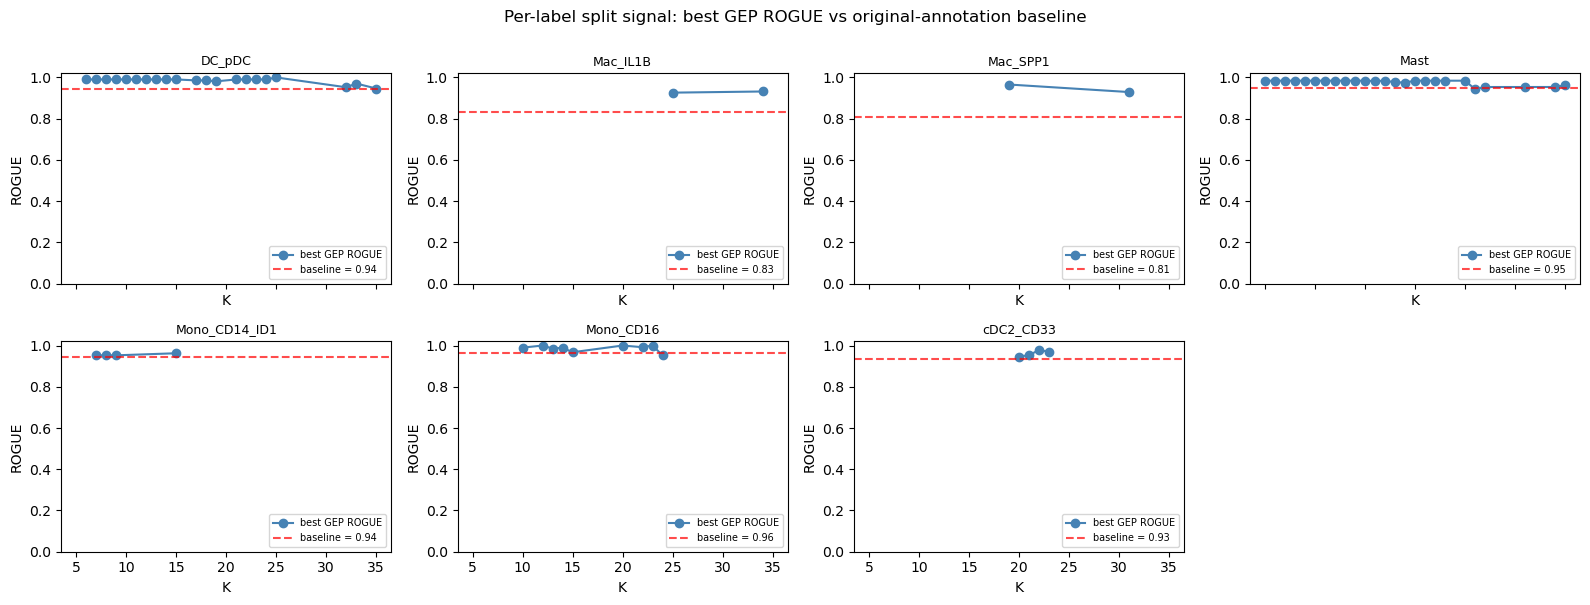

In [15]:
# 9a — Per-label split signal across K

specific_audit = audit_df[audit_df['label_kind'] == 'specific'].copy()

# best (K, GEP) per (label, K): max ROGUE across GEPs and samples carrying that label
per_label_best = (specific_audit
                  .groupby(['label', 'K'])
                  .agg(best_ROGUE=('ROGUE', 'max'),
                       n_rows    =('ROGUE', 'count'))
                  .reset_index())

# Median baseline across samples for that label (line on each subplot)
baseline_by_label = (baseline_specific
                     .groupby('original_label')['ROGUE']
                     .median()
                     .to_dict())

labels_present = sorted(per_label_best['label'].unique())
n = len(labels_present)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3), sharex=True)
axes = np.atleast_2d(axes).ravel()

for ax, lbl in zip(axes, labels_present):
    df = per_label_best[per_label_best['label'] == lbl].sort_values('K')
    ax.plot(df['K'], df['best_ROGUE'], marker='o', color='steelblue',
            label='best GEP ROGUE')
    base = baseline_by_label.get(lbl, np.nan)
    if not pd.isna(base):
        ax.axhline(base, ls='--', color='red', alpha=0.7,
                   label=f'baseline = {base:.2f}')
    ax.set_title(lbl, fontsize=9)
    ax.set_ylabel('ROGUE')
    ax.set_xlabel('K')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=7, loc='lower right')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Per-label split signal: best GEP ROGUE vs original-annotation baseline",
             y=1.00, fontsize=12)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_label_split_signal.png", dpi=150, bbox_inches='tight')
plt.show()

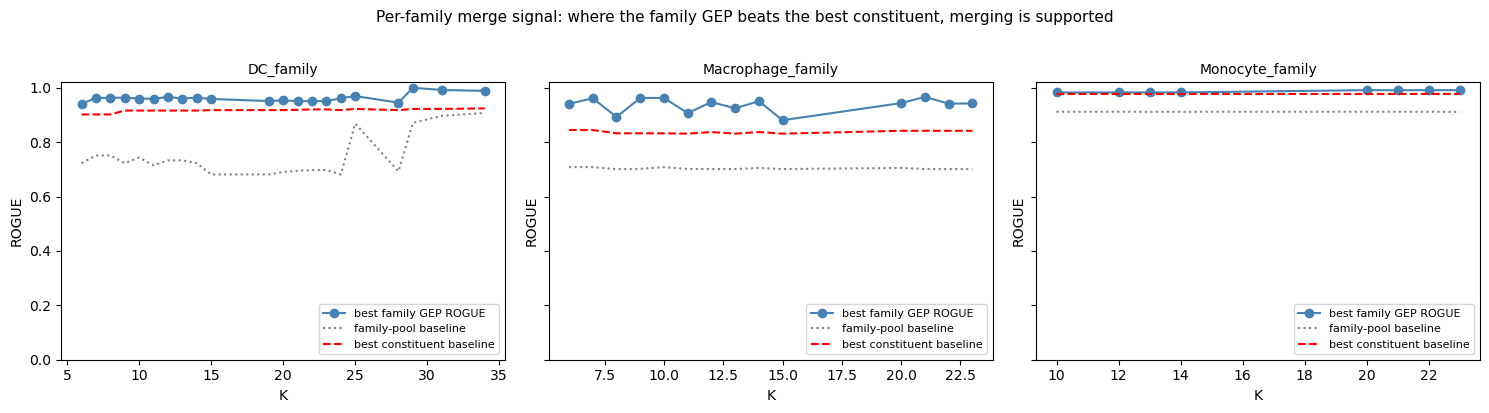

In [16]:
# 9b — Per-family merge signal across K

family_audit = audit_df[audit_df['label_kind'] == 'family'].copy()

per_family_best = (family_audit
                   .groupby(['label', 'K'])
                   .agg(best_ROGUE     =('ROGUE', 'max'),
                        med_pool_base  =('baseline_ROGUE',      'median'),
                        med_mean_base  =('baseline_ROGUE_mean', 'median'),
                        med_max_base   =('baseline_ROGUE_max',  'median'))
                   .reset_index())

families_present = sorted(per_family_best['label'].unique())
n = len(families_present)
fig, axes = plt.subplots(1, n, figsize=(5 * n, 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, fam_lbl in zip(axes, families_present):
    df = per_family_best[per_family_best['label'] == fam_lbl].sort_values('K')
    ax.plot(df['K'], df['best_ROGUE'],   marker='o', color='steelblue',
            label='best family GEP ROGUE')
    ax.plot(df['K'], df['med_pool_base'], ls=':',  color='gray',
            label='family-pool baseline')
    ax.plot(df['K'], df['med_max_base'],  ls='--', color='red',
            label='best constituent baseline')
    ax.set_title(fam_lbl, fontsize=10)
    ax.set_xlabel('K')
    ax.set_ylabel('ROGUE')
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle("Per-family merge signal: where the family GEP beats the best constituent, merging is supported",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/per_family_merge_signal.png", dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-label aggregate 

Collapse `audit_df` to one row per label, recording:

* `best_GEP_ROGUE` — the highest ROGUE achieved by any GEP carrying this label, across all K and samples.
* `K_at_best`, `GEP_at_best`, `sample_at_best` — where that peak was found.
* `baseline_ROGUE_median` — the per-label baseline aggregated across samples.
* `best_delta_ROGUE` — `best_GEP_ROGUE` minus the corresponding baseline at `sample_at_best`. This is the headline split/merge signal.
* `n_K_with_signal` — number of K values at which at least one GEP achieved Δ ROGUE ≥ `DELTA_ROGUE_THRESHOLD` (a persistence-style count).

In [17]:
def _per_label_aggregate(df, kind):
    rows = []
    for lbl, sub in df.groupby('label'):
        if sub['ROGUE'].notna().sum() == 0:
            continue
        idx = sub['ROGUE'].idxmax()
        best = sub.loc[idx]

        if kind == 'specific':
            base_median = (baseline_specific[baseline_specific['original_label'] == lbl]
                           ['ROGUE'].median())
            best_delta = best['ROGUE'] - base_median if not pd.isna(base_median) else np.nan
        elif kind == 'family':
            base_median = (baseline_family[baseline_family['family_label'] == lbl]
                           ['ROGUE'].median())
            # for families also record the median across constituents (best of them)
            fam = lbl[:-len(FAMILY_LABEL_SUFFIX)]
            members = CELLTYPE_FAMILIES.get(fam, [])
            constituent_max_medians = []
            for s in sub['sample'].unique():
                vals = [baseline_specific_lookup.get((s, m)) for m in members]
                vals = [v for v in vals if v is not None and not np.isnan(v)]
                if vals:
                    constituent_max_medians.append(max(vals))
            median_best_constituent = (float(np.median(constituent_max_medians))
                                       if constituent_max_medians else np.nan)
            best_delta = best['ROGUE'] - base_median if not pd.isna(base_median) else np.nan
        else:
            base_median = np.nan
            best_delta  = np.nan
            median_best_constituent = np.nan

        # Persistence: how many distinct K values had ANY GEP exceeding threshold?
        sig = (sub[sub.get('delta_ROGUE', np.nan).fillna(-np.inf)
                   >= DELTA_ROGUE_THRESHOLD]
               if kind == 'specific'
               else sub[sub.get('delta_ROGUE_vs_max', np.nan).fillna(-np.inf)
                        >= DELTA_ROGUE_THRESHOLD])
        n_K_with_signal = sig['K'].nunique()

        row = {
            'label':                  lbl,
            'label_kind':             kind,
            'best_GEP_ROGUE':         best['ROGUE'],
            'K_at_best':              int(best['K']),
            'GEP_at_best':            best['gep'],
            'sample_at_best':         best['sample'],
            'baseline_ROGUE_median':  base_median,
            'best_delta_ROGUE':       best_delta,
            'n_K_with_signal':        n_K_with_signal,
            'n_rows':                 len(sub),
        }
        if kind == 'family':
            row['median_best_constituent_baseline'] = median_best_constituent
        rows.append(row)
    return pd.DataFrame(rows)

per_label_specific = _per_label_aggregate(
    audit_df[audit_df['label_kind'] == 'specific'], 'specific')
per_label_family   = _per_label_aggregate(
    audit_df[audit_df['label_kind'] == 'family'],   'family')

per_label_agg = pd.concat([per_label_specific, per_label_family],
                          ignore_index=True, sort=False)
per_label_agg = per_label_agg.sort_values(
    ['label_kind', 'best_delta_ROGUE'],
    ascending=[True, False],
    na_position='last',
).reset_index(drop=True)

out = os.path.join(OUT_DIR, "rogue_per_label_aggregate.csv")
per_label_agg.to_csv(out, index=False)
print(f"Saved per-label aggregate → {out}")
per_label_agg

Saved per-label aggregate → rogue_purity_results_per_gep/rogue_per_label_aggregate.csv


,label,label_kind,best_GEP_ROGUE,K_at_best,GEP_at_best,sample_at_best,baseline_ROGUE_median,best_delta_ROGUE,n_K_with_signal,n_rows,median_best_constituent_baseline
0,Macrophage_family,family,0.966563,21,3,GSM4138143,0.712397,0.254167,12,293,0.850719
1,DC_family,family,1.000000,29,3,GSM4138116,0.898821,0.101179,15,664,0.922218
2,Monocyte_family,family,0.991339,22,1,GSM4138132,0.911895,0.079444,3,414,0.977185
3,Mac_SPP1,specific,0.965779,19,1,GSM4138132,0.808414,0.157364,1,55,NaN
4,Mac_IL1B,specific,0.931949,34,3,GSM4138111,0.831312,0.100637,0,32,NaN
5,DC_pDC,specific,1.000000,25,4,GSM4138157,0.944275,0.055725,3,734,NaN
6,cDC2_CD33,specific,0.977712,22,2,GSM4138159,0.934087,0.043625,0,207,NaN
7,Mono_CD16,specific,1.000000,12,2,GSM4138129,0.964002,0.035998,2,412,NaN
8,Mast,specific,0.984348,5,5,GSM4138117,0.949910,0.034438,5,159,NaN
9,Mono_CD14_ID1,specific,0.962574,15,1,GSM4138124,0.943186,0.019388,0,221,NaN
